In [1]:
from PIL import Image

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import random

import os

from model import CGenerator, CDiscriminator


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # For reproducibility (may slow down training)
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False

In [3]:
set_seed(1)

In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [5]:
# get mnist data
data_dir = './data'
os.makedirs(data_dir,exist_ok=True)
mnist_train_dataset = datasets.MNIST(data_dir, train=True, download=True, transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]))

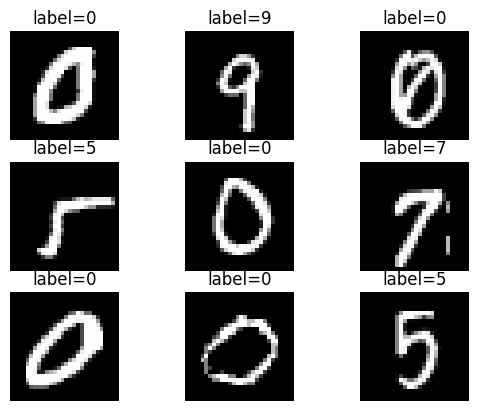

In [6]:
# plot 9 random sample images from a mnist dataset (train or test)
def plot_9_sample_images(dataset):
    fig, axs = plt.subplots(3, 3)
    indices = np.random.choice(len(dataset), 9)
    for i, idx in enumerate(indices):
        axs[np.unravel_index(i, (3,3))].imshow(dataset[idx][0].squeeze(), cmap="gray")
        axs[np.unravel_index(i, (3,3))].set_title(f"label={dataset[idx][1]}")
        axs[np.unravel_index(i, (3,3))].set_axis_off()
    plt.show()
    

plot_9_sample_images(mnist_train_dataset)
    

In [7]:
def stack_vectors_along_image_channel(input, vectors):
    # input Nx1x28x28
    # vectors Nxd
    # output Nx(d+1)x28x28
    
    vectors = vectors.unsqueeze(-1).unsqueeze(-1).expand(-1,-1,input.shape[-2], input.shape[-1]) # Nxdx28x28
    
    return torch.cat((input, vectors), dim=1)

input = torch.rand((2,1,3,3))
print(input)
vectors = torch.tensor([[1,0],[0,1]])
print(vectors)
print("")
print(stack_vectors_along_image_channel(input, vectors))


tensor([[[[0.7576, 0.2793, 0.4031],
          [0.7347, 0.0293, 0.7999],
          [0.3971, 0.7544, 0.5695]]],


        [[[0.4388, 0.6387, 0.5247],
          [0.6826, 0.3051, 0.4635],
          [0.4550, 0.5725, 0.4980]]]])
tensor([[1, 0],
        [0, 1]])

tensor([[[[0.7576, 0.2793, 0.4031],
          [0.7347, 0.0293, 0.7999],
          [0.3971, 0.7544, 0.5695]],

         [[1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000]],

         [[0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000]]],


        [[[0.4388, 0.6387, 0.5247],
          [0.6826, 0.3051, 0.4635],
          [0.4550, 0.5725, 0.4980]],

         [[0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000]],

         [[1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000]]]])


In [8]:
# compute losses


def discriminator_loss(batch_real_data, batch_gen_data, discriminator_model):
    loss = nn.BCEWithLogitsLoss()
    logits_real = discriminator_model(batch_real_data)
    logits_fake = discriminator_model(batch_gen_data)
    loss_D  = loss(logits_real, torch.ones_like(logits_real).to(device)) + loss(logits_fake, torch.zeros_like(logits_fake).to(device))
    return loss_D, logits_real, logits_fake

def discriminator_wasserstein_loss(batch_real_data, batch_gen_data, discriminator_model):
    pass

def generator_loss(z,c, discriminator_model, generator_model):
    loss = nn.BCEWithLogitsLoss()
    batch_gen_data = generator_model(z, c)
    batch_gen_data = stack_vectors_along_image_channel(batch_gen_data, c)
    logits_fake = discriminator_model(batch_gen_data) 
    return loss(logits_fake, torch.ones_like(logits_fake).to(device))
    

In [9]:
# weights initialization
def weights_init_dcgan(m):    
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

    elif isinstance(m, nn.BatchNorm1d) or isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [10]:
# define model
generator = CGenerator()
generator.to(device)

discriminator = CDiscriminator()
discriminator.to(device)

generator.apply(weights_init_dcgan)
discriminator.apply(weights_init_dcgan)


CDiscriminator(
  (down1): Conv2d(11, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (down2): Conv2d(256, 512, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Conv2d(512, 1, kernel_size=(7, 7), stride=(1, 1))
)

In [11]:
learning_rate = 2e-4
batch_size = 64
epochs = 25

In [12]:
train_dataloader = DataLoader(mnist_train_dataset, batch_size=batch_size)

In [13]:
# Display image and label.
print(f"length of the dataloader = {len(train_dataloader)}")
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")


length of the dataloader = 938
Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


In [14]:
# optimizer
betas = (0.5, 0.999)
optimizer_G = torch.optim.Adam(generator.parameters(), learning_rate, betas)
optimizer_D = torch.optim.Adam(discriminator.parameters(), learning_rate, betas)

In [15]:
def update_D(real_data, gen_data, discriminator, number_of_update, optimizer_D):
    loss = 0
    D_real = 0
    D_fake = 0
    
    for i in range(number_of_update):
        optimizer_D.zero_grad()
        loss_D, logits_real, logits_fake = discriminator_loss(real_data, gen_data, discriminator)
        loss_D.backward()
        optimizer_D.step()
        loss = loss_D.item()
        with torch.no_grad():
            D_real = torch.sigmoid(logits_real).mean().item()
            D_fake = torch.sigmoid(logits_fake).mean().item()
        
    return loss, D_real, D_fake
    
        
def update_G(z,c, discriminator, generator, number_of_update, optimizer_G):
    loss = 0
    for i in range(number_of_update):
        optimizer_G.zero_grad()
        loss_G = generator_loss(z,c, discriminator, generator)
        loss_G.backward()
        optimizer_G.step()
        loss = loss_G.item()
    return loss

In [ ]:
def training_loop(generator, discriminator, train_dataloader, epochs, batch_size, optimizer_G, optimizer_D):
    
    z_fixed = torch.randn(64, 100, device=device)
    c_fixed = F.one_hot(torch.randint(0,10, (64,)), 10).to(device)
    
    
    os.makedirs("./output/samples_from_cgan",exist_ok=True)
    losses_D = []
    losses_G = []
    D_real_hist = []
    D_fake_hist = []

    for epoch in range(epochs):
        
        epoch_loss_D = 0 
        epoch_loss_G = 0 
        epoch_D_real = 0.0
        epoch_D_fake = 0.0
        
        generator.eval()
        with torch.no_grad():
            fake = generator(z_fixed, c_fixed).cpu()
            fake = (fake + 1) / 2.0  # [-1,1] -> [0,1]
            save_image(fake.clamp(0,1), f"./output/samples_from_cgan/epoch_{epoch+1:03d}.png", nrow=8,  normalize=False)
        generator.train()
      
        
        
        for i, data in enumerate(train_dataloader):
            real_data, real_class = data
            real_data = real_data.to(device)
            real_class = F.one_hot(real_class.to(device), 10)
            
            real_data = stack_vectors_along_image_channel(real_data, real_class)
            
            z = torch.rand((real_data.shape[0], 100)).to(device)
            c = F.one_hot(torch.randint(0,10, (real_data.shape[0],)), 10).to(device)
            gen_data = generator(z,c)
            gen_data_detached = gen_data.detach()
            gen_data_detached = stack_vectors_along_image_channel(gen_data_detached, c)
            

            loss_D, D_real, D_fake = update_D(real_data, gen_data_detached, discriminator, 1, optimizer_D)
            loss_G = update_G(z,c, discriminator, generator, 1, optimizer_G)
            
            epoch_loss_D += loss_D / len(train_dataloader)
            epoch_loss_G += loss_G / len(train_dataloader)
            epoch_D_real += D_real / len(train_dataloader)
            epoch_D_fake += D_fake / len(train_dataloader)
            
            if i%50==0:
                print(f'Epoch/Batch_index {epoch+1}/{i} batch_loss_D {loss_D:.3f}, batch_loss_G {loss_G:.3f}')
                
        losses_D.append(epoch_loss_D)
        losses_G.append(epoch_loss_G)
        D_real_hist.append(epoch_D_real)
        D_fake_hist.append(epoch_D_fake)
        
        print(
        f"Epoch {epoch+1:03d} | "
        f"Loss D: {epoch_loss_D:.4f} | "
        f"Loss G: {epoch_loss_G:.4f} | "
        f"D(real): {epoch_D_real:.3f} | "
        f"D(fake): {epoch_D_fake:.3f}"
        )
    
    return losses_D, losses_G, D_real_hist, D_fake_hist
        
    

In [17]:
losses_D, losses_G, D_real_hist, D_fake_hist = training_loop(generator, discriminator, train_dataloader, epochs, batch_size, optimizer_G, optimizer_D)

Epoch/Batch_index 1/0 batch_loss_D 2.738, batch_loss_G 4.039
Epoch/Batch_index 1/50 batch_loss_D 2.834, batch_loss_G 3.837
Epoch/Batch_index 1/100 batch_loss_D 1.931, batch_loss_G 4.033
Epoch/Batch_index 1/150 batch_loss_D 0.693, batch_loss_G 2.636
Epoch/Batch_index 1/200 batch_loss_D 1.565, batch_loss_G 1.191
Epoch/Batch_index 1/250 batch_loss_D 2.719, batch_loss_G 0.482
Epoch/Batch_index 1/300 batch_loss_D 1.160, batch_loss_G 2.282
Epoch/Batch_index 1/350 batch_loss_D 0.867, batch_loss_G 2.426
Epoch/Batch_index 1/400 batch_loss_D 1.057, batch_loss_G 0.755
Epoch/Batch_index 1/450 batch_loss_D 0.714, batch_loss_G 2.007
Epoch/Batch_index 1/500 batch_loss_D 1.595, batch_loss_G 0.938
Epoch/Batch_index 1/550 batch_loss_D 1.108, batch_loss_G 1.218
Epoch/Batch_index 1/600 batch_loss_D 0.896, batch_loss_G 1.403
Epoch/Batch_index 1/650 batch_loss_D 1.017, batch_loss_G 1.543
Epoch/Batch_index 1/700 batch_loss_D 1.617, batch_loss_G 1.175
Epoch/Batch_index 1/750 batch_loss_D 1.507, batch_loss_G 1

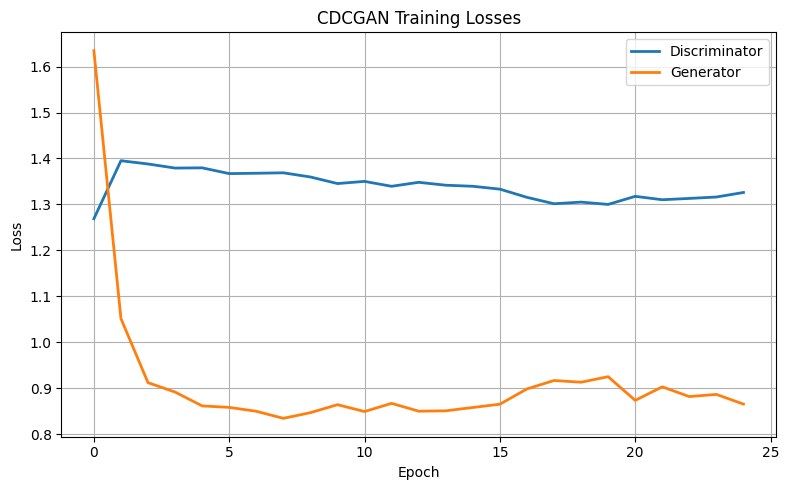

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(losses_D, label="Discriminator", linewidth=2)
plt.plot(losses_G, label="Generator", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CDCGAN Training Losses")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("c_training_losses.png", dpi=150)
plt.show()

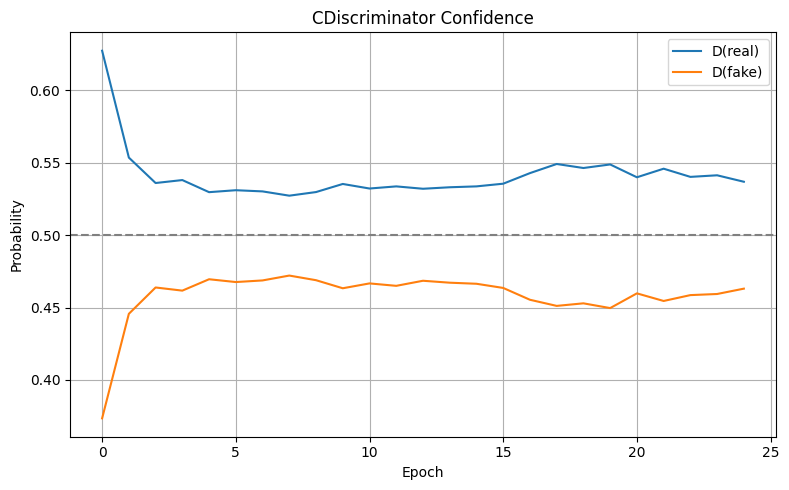

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(D_real_hist, label="D(real)")
plt.plot(D_fake_hist, label="D(fake)")
plt.axhline(0.5, linestyle="--", color="gray")

plt.xlabel("Epoch")
plt.ylabel("Probability")
plt.title("CDiscriminator Confidence")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("c_discriminator_confidence.png", dpi=150)
plt.show()

class: 4


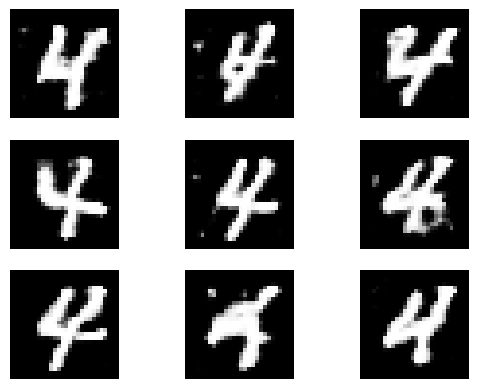

In [23]:
# see what is generated 
z = torch.rand(9,100).to(device)
c = random.randrange(10)
print(f"class: {c}")
c = F.one_hot(c * torch.ones(9, dtype=torch.long), 10).to(device)
generator.eval()
generated_images = generator(z,c)
generated_images = generated_images.cpu()

fig, axs = plt.subplots(3, 3)
for i in range(generated_images.shape[0]):
    axs[np.unravel_index(i, (3,3))].imshow(generated_images[i].squeeze().detach().numpy(), cmap="gray")
    axs[np.unravel_index(i, (3,3))].set_axis_off()
plt.show()
